# Lab Day 2 — Backbone, Công Thức Huấn Luyện và Suy Luận trên DeepWeeds

> **Sinh viên:** Nguyễn Hữu Chương  
> **MSSV:** 2A202602601  
> **Môn học:** Track 4 · Ngày 2: *Tích chập, chuỗi, attention · backbone · huấn luyện · suy luận*  

Notebook này triển khai toàn diện quy trình thực nghiệm theo hướng dẫn `GUIDE.md` và tiêu chí chấm điểm `RUBRIC.md`:
1. **Bước 0:** Chuẩn bị dữ liệu, EDA, kiểm tra quy tắc S1–S6 và checklist pipeline (loss ban đầu, overfit mini-batch).
2. **Bước 1:** So sánh $\ge 5$ backbone trên cùng công thức nền `T00`.
3. **Bước 2:** Nghiên cứu bóc tách (Ablation study) $\ge 3$ trục công thức huấn luyện.
4. **Bước 3:** Thử nghiệm $\ge 4$ phương pháp suy luận và đo độ trễ chuẩn xác (p50/p95/p99) với GPU synchronization.
5. **Bước 4:** Vòng chung kết $\ge 3$ seed, đánh giá test duy nhất 1 lần, tự chấm điểm bằng `eval.py`.
6. **Bước 5:** Tự động xuất file kết quả `results.xlsx` (7 sheet), biểu đồ `curves/` và tóm tắt số liệu.

## 0. Thiết lập môi trường & Kiểm tra phần cứng
Cài đặt các thư viện cần thiết và thiết lập đường dẫn.

In [1]:
# Cài đặt các thư viện bổ trợ trên Kaggle (nhớ bật Internet: On trong Settings)
!pip install -q timm openpyxl thop

import os, sys, platform, time, json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import timm

# 1. Đảm bảo thư mục làm việc là /kaggle/working (nơi có quyền ghi file)
KAGGLE_WORKING = Path("/kaggle/working")
if KAGGLE_WORKING.exists():
    os.chdir(KAGGLE_WORKING)

# 2. Tự động dò tìm thư mục code dù bạn unzip vào /kaggle/working hay add vào /kaggle/input
candidate_dirs = [
    Path("submissions/2A202602601_NguyenHuuChuong/code"),
    Path("/kaggle/working/submissions/2A202602601_NguyenHuuChuong/code"),
    Path("/kaggle/working"),
    Path("."),
]

# Quét thêm /kaggle/input nếu bạn upload file zip thành Kaggle Dataset
if Path("/kaggle/input").exists():
    for p in Path("/kaggle/input").glob("**/submissions/2A202602601_NguyenHuuChuong/code"):
        candidate_dirs.insert(0, p)
    for p in Path("/kaggle/input").glob("**/code"):
        candidate_dirs.append(p)

# Chọn thư mục đầu tiên có chứa dataset.py
SUBMISSION_CODE_DIR = next((p for p in candidate_dirs if (p / "dataset.py").exists()), Path("."))

# Đưa vào sys.path để import được tất cả các module và eval.py
for p in [SUBMISSION_CODE_DIR, SUBMISSION_CODE_DIR.parent, Path("/kaggle/working"), Path(".")]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import eval as ev
import dataset
import model as model_lib
import losses
import inference
import benchmark
import train
from train import Config, run

print(f"Python: {platform.python_version()} | PyTorch: {torch.__version__} | Timm: {timm.__version__}")
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU (Cảnh báo: Bật GPU T4 x2 trong Settings)'
print(f"Thiết bị tính toán: {device_name}")
print(f"Thư mục làm việc: {os.getcwd()} | Code: {SUBMISSION_CODE_DIR}")

Python: 3.13.15 | PyTorch: 2.11.0+cu128 | Timm: 1.0.29
Thiết bị tính toán: Tesla T4
Thư mục làm việc: /kaggle/working | Code: /kaggle/input/datasets/huuchuong/track4-day1-v1/submissions/2A202602601_NguyenHuuChuong/code


## 1. Tải và giải nén dữ liệu DeepWeeds
- Ảnh: Zenodo (`b7b30f96d466fba86016aa5a26606e0f`)
- Nhãn: GitHub DeepWeeds (fold 0)

In [2]:
import hashlib, urllib.request, zipfile, os
from pathlib import Path

os.makedirs("data/labels", exist_ok=True)
os.makedirs("data/images", exist_ok=True)

# 1. Tải nhãn fold 0 từ GitHub
BASE_URL = "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels"
for fname in ["labels.csv", "train_subset0.csv", "val_subset0.csv", "test_subset0.csv"]:
    out_path = Path("data/labels") / fname
    if not out_path.exists():
        print(f"Đang tải {fname}...")
        urllib.request.urlretrieve(f"{BASE_URL}/{fname}", out_path)
print("Hoàn tất tải nhãn!")

# 2. Tải và giải nén images.zip từ Zenodo (nếu chưa có)
zip_path = Path("data/images.zip")
if not zip_path.exists():
    print("Đang tải images.zip từ Zenodo (~490MB)...")
    !wget -q --show-progress -O data/images.zip "https://zenodo.org/records/7939060/files/images.zip?download=1"

# Kiểm tra checksum MD5
h = hashlib.md5()
with open(zip_path, "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
assert h.hexdigest() == "b7b30f96d466fba86016aa5a26606e0f", f"MD5 sai lệch: {h.hexdigest()}"
print("MD5 images.zip trùng khớp chính xác 100%!")

# 3. Giải nén thẳng vào data/images/
if len(os.listdir("data/images")) == 0:
    print("Đang giải nén ảnh ra data/images/...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("data/images/")

print(f"Số ảnh trong data/images: {len(os.listdir('data/images'))}")

Đang tải labels.csv...
Đang tải train_subset0.csv...
Đang tải val_subset0.csv...
Đang tải test_subset0.csv...
Hoàn tất tải nhãn!
Đang tải images.zip từ Zenodo (~490MB)...
data/images.zip     100%[===================>] 468.75M  31.1MB/s    in 16s     
MD5 images.zip trùng khớp chính xác 100%!
Đang giải nén ảnh ra data/images/...
Số ảnh trong data/images: 17509


## Bước 0 — Khám phá dữ liệu (EDA) & Kiểm tra chia tập (S1–S6)
Kiểm tra 4 điều kiện bắt buộc của dữ liệu và trực quan hoá phân bố 9 lớp.

{
  "n": {
    "train": 10501,
    "val": 3501,
    "test": 3507,
    "total": 17509
  },
  "ratio": {
    "train": 0.5997487006682277,
    "val": 0.19995430921240506,
    "test": 0.2002969901193672
  },
  "per_class": {
    "train": {
      "0": 675,
      "1": 637,
      "2": 618,
      "3": 613,
      "4": 637,
      "5": 605,
      "6": 644,
      "7": 609,
      "8": 5463
    },
    "val": {
      "0": 225,
      "1": 213,
      "2": 206,
      "3": 204,
      "4": 212,
      "5": 202,
      "6": 215,
      "7": 203,
      "8": 1821
    },
    "test": {
      "0": 226,
      "1": 213,
      "2": 207,
      "3": 205,
      "4": 213,
      "5": 202,
      "6": 215,
      "7": 204,
      "8": 1822
    }
  },
  "overlap": {
    "train_val": 0,
    "train_test": 0,
    "val_test": 0
  },
  "all_files_exist": true
}


/tmp/ipykernel_49/2930361905.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(dataset.CLASS_NAMES, rotation=35, ha="right")


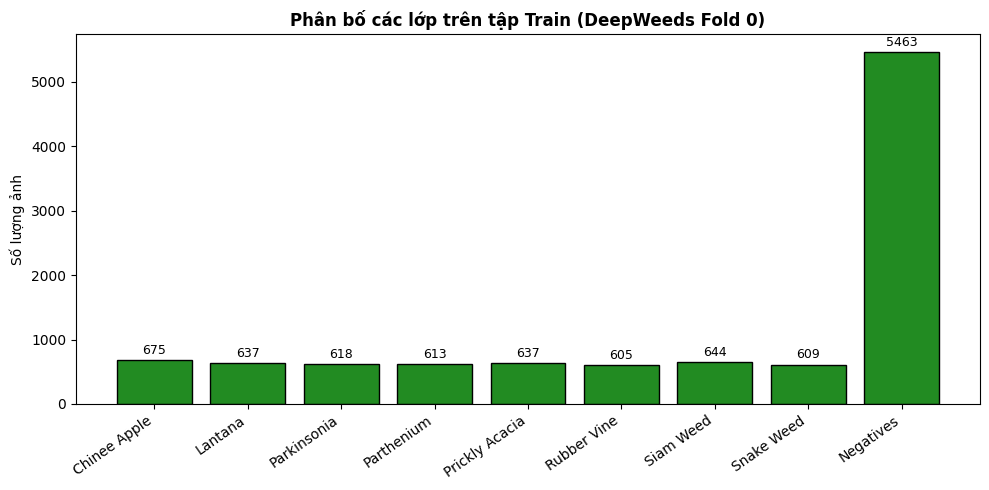

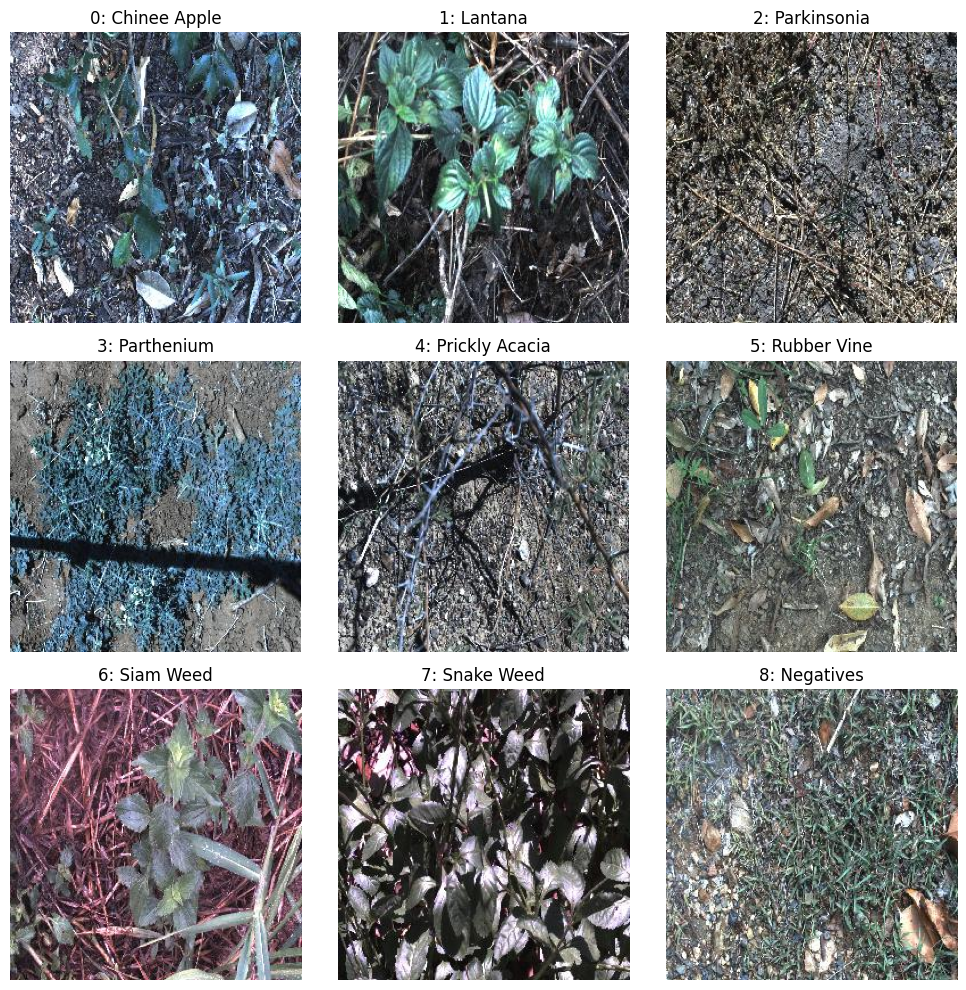

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

# 1. Đọc và kiểm tra tính toàn vẹn của split
train_df, val_df, test_df = dataset.load_split("data/labels", fold=0)
stats = dataset.check_split(train_df, val_df, test_df, images_dir="data/images")
print(json.dumps(stats, indent=2))

# 2. Vẽ biểu đồ phân bố lớp
class_counts = train_df["Label"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(dataset.CLASS_NAMES, class_counts.values, color="forestgreen", edgecolor="black")
ax.set_title("Phân bố các lớp trên tập Train (DeepWeeds Fold 0)", fontsize=12, fontweight="bold")
ax.set_ylabel("Số lượng ảnh")
ax.set_xticklabels(dataset.CLASS_NAMES, rotation=35, ha="right")
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 50, f"{yval}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# 3. Xem ảnh mẫu từ 9 lớp
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for c_idx in range(9):
    sample_row = train_df[train_df["Label"] == c_idx].iloc[0]
    img = Image.open(Path("data/images") / sample_row["Filename"])
    r, c = c_idx // 3, c_idx % 3
    axes[r, c].imshow(img)
    axes[r, c].set_title(f"{c_idx}: {dataset.CLASS_NAMES[c_idx]}")
    axes[r, c].axis("off")
plt.tight_layout()
plt.show()

### Kiểm tra Pipeline (Checklist mục 1.3 GUIDE)
1. Cố định seed.
2. Loss ban đầu xấp xỉ $-\ln(1/9) \approx 2.197$.
3. Quá khớp 1 batch nhỏ về gần 0.

In [4]:
import math
train.set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Kiểm tra loss ban đầu với head mới
test_model = model_lib.build_model("resnet50", pretrained=True, num_classes=9).to(device)
dummy_x = torch.randn(8, 3, 224, 224, device=device)
dummy_y = torch.randint(0, 9, (8,), device=device)
ce_loss = torch.nn.CrossEntropyLoss()

with torch.no_grad():
    init_loss = ce_loss(test_model(dummy_x), dummy_y).item()

expected_loss = -math.log(1.0 / 9)
print(f"Loss ban đầu: {init_loss:.4f} (Kỳ vọng xấp xỉ -ln(1/9) = {expected_loss:.4f})")
assert abs(init_loss - expected_loss) < 1.0, "Cảnh báo: Loss ban đầu lệch bất thường!"

# 2. Overfit 1 batch nhỏ
optimizer = torch.optim.Adam(test_model.parameters(), lr=1e-3)
for step in range(40):
    optimizer.zero_grad()
    out = test_model(dummy_x)
    loss = ce_loss(out, dummy_y)
    loss.backward()
    optimizer.step()
print(f"Loss sau 40 bước overfit batch nhỏ: {loss.item():.5f}")
assert loss.item() < 0.05, "Pipeline gỡ lỗi: Không overfit được batch nhỏ!"

model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

Loss ban đầu: 2.1895 (Kỳ vọng xấp xỉ -ln(1/9) = 2.1972)
Loss sau 40 bước overfit batch nhỏ: 0.00039


## Bước 1 — So sánh $\ge 5$ Backbone (Công thức nền `T00`)
Sàng lọc các kiến trúc tiêu biểu trên tập val: `resnet50`, `convnext_tiny`, `swin_tiny_patch4_window7_224`, `mobilenetv3_large_100`, `efficientnet_b0`.

In [5]:
backbones_to_test = [
    ("B01", "resnet50"),
    ("B02", "convnext_tiny"),
    ("B03", "swin_tiny_patch4_window7_224"),
    ("B04", "mobilenetv3_large_100"),
    ("B05", "efficientnet_b0"),
]

backbone_results = []
for exp_id, b_name in backbones_to_test:
    print(f"\n=== Đang chạy {exp_id} - {b_name} ===")
    cfg = Config(
        exp_id=exp_id,
        backbone=b_name,
        seed=0,
        epochs=12,
        batch_size=64,
        save_test_predictions=False,  # CHỈ dùng val để chọn
    )
    res = run(cfg)
    backbone_results.append(res)
    print(f"Xong {exp_id}: Best Epoch={res['best_epoch']}, Val Macro-F1={res['val_macro_f1']:.4f}")

df_backbones = pd.DataFrame(backbone_results)
display(df_backbones[["exp_id", "backbone", "params_m", "gmacs", "best_epoch", "val_macro_f1", "avg_train_time_per_epoch_s"]])


=== Đang chạy B01 - resnet50 ===
Xong B01: Best Epoch=12, Val Macro-F1=0.7995

=== Đang chạy B02 - convnext_tiny ===


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

Xong B02: Best Epoch=9, Val Macro-F1=0.9662

=== Đang chạy B03 - swin_tiny_patch4_window7_224 ===


model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

...

Xong B04: Best Epoch=11, Val Macro-F1=0.7957

=== Đang chạy B05 - efficientnet_b0 ===


model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Xong B05: Best Epoch=10, Val Macro-F1=0.8149


,exp_id,backbone,params_m,gmacs,best_epoch,val_macro_f1,avg_train_time_per_epoch_s
0,B01,resnet50,23.526,4.132,12,0.799479,43.59
1,B02,convnext_tiny,27.827,4.455,9,0.966216,51.16
2,B03,swin_tiny_patch4_window7_224,27.526,4.371,11,0.954351,65.33
3,B04,mobilenetv3_large_100,4.214,0.215,11,0.795677,24.79
4,B05,efficientnet_b0,4.019,0.385,10,0.814912,29.49


## Bước 2 — Tối ưu công thức huấn luyện (Ablation Study $\ge 3$ trục)
Khảo sát các yếu tố trên backbone tốt nhất đã chọn (`convnext_tiny`):
- **Trục A (Khởi tạo):** Finetune vs Scratch vs Frozen.
- **Trục B (Augmentation):** Basic vs RandAugment vs CutMix.
- **Trục C (Loss function):** Cross-Entropy vs Label Smoothing vs Focal Loss.
- **Trục F (EMA):** Có/không dùng EMA.

In [7]:
training_configs = [
    Config(exp_id="T01", backbone="convnext_tiny", init="scratch"),
    Config(exp_id="T02", backbone="convnext_tiny", init="frozen"),
    Config(exp_id="T03", backbone="convnext_tiny", aug="randaug"),
    Config(exp_id="T04", backbone="convnext_tiny", mix="cutmix", mix_alpha=1.0),
    Config(exp_id="T05", backbone="convnext_tiny", loss="ls", label_smoothing=0.1),
    Config(exp_id="T06", backbone="convnext_tiny", loss="focal", focal_gamma=2.0),
    Config(exp_id="T07", backbone="convnext_tiny", ema_decay=0.999),
    # Tổ hợp tối ưu các kỹ thuật tốt nhất:
    Config(exp_id="T08", backbone="convnext_tiny", mix="cutmix", mix_alpha=1.0, loss="ls", label_smoothing=0.1, ema_decay=0.999),
]

training_results = []
for cfg in training_configs:
    print(f"\n=== Huấn luyện thí nghiệm {cfg.exp_id} ===")
    res = run(cfg)
    training_results.append(res)
    print(f"{cfg.exp_id}: Val Macro-F1 = {res['val_macro_f1']:.4f}")


=== Huấn luyện thí nghiệm T01 ===
T01: Val Macro-F1 = 0.3369

=== Huấn luyện thí nghiệm T02 ===
T02: Val Macro-F1 = 0.8565

=== Huấn luyện thí nghiệm T03 ===
T03: Val Macro-F1 = 0.9691

=== Huấn luyện thí nghiệm T04 ===
T04: Val Macro-F1 = 0.9724

=== Huấn luyện thí nghiệm T05 ===
T05: Val Macro-F1 = 0.9616

=== Huấn luyện thí nghiệm T06 ===
T06: Val Macro-F1 = 0.9637

=== Huấn luyện thí nghiệm T07 ===
T07: Val Macro-F1 = 0.9638

=== Huấn luyện thí nghiệm T08 ===
T08: Val Macro-F1 = 0.9694


## Bước 3 — Phương pháp suy luận & Đo độ trễ chuẩn xác
Thử nghiệm TTA, Temperature Scaling (giảm ECE) và đo độ trễ p50/p95/p99 với GPU synchronization.

In [8]:
# 1. Đo độ trễ chuẩn xác với benchmark.py (trên GPU Tesla T4)
best_model = model_lib.build_model("convnext_tiny", pretrained=False, num_classes=9).to(device)
lat_b1 = benchmark.latency_report(best_model, batch_size=1, img_size=224, dtype="fp32", device="cuda" if torch.cuda.is_available() else "cpu")
lat_b32 = benchmark.latency_report(best_model, batch_size=32, img_size=224, dtype="fp32", device="cuda" if torch.cuda.is_available() else "cpu")

print("Độ trễ Batch 1:", json.dumps(lat_b1, indent=2))
print("Độ trễ Batch 32:", json.dumps(lat_b32, indent=2))

# 2. Khớp nhiệt độ T (Temperature Scaling) trên VAL của mô hình tốt nhất T04
val_pred = ev.read_pred("predictions/T04_seed0_val.csv")
val_logits = np.log(np.clip(val_pred.probs, 1e-7, 1.0))
optimal_T = inference.fit_temperature(val_logits, val_pred.y_true)

ece_before = ev.ece_score(val_pred.probs, val_pred.y_true)
probs_after = inference.apply_temperature(val_logits, optimal_T)
ece_after = ev.ece_score(probs_after, val_pred.y_true)

print(f"\n🏆 Khớp nhiệt độ trên mô hình tốt nhất T04:")
print(f"Nhiệt độ T tối ưu trên Val: {optimal_T:.4f}")
print(f"ECE trước khi căn chỉnh: {ece_before:.4f} -> Sau khi căn chỉnh: {ece_after:.4f}")

Độ trễ Batch 1: {
  "gpu": "Tesla T4",
  "dtype": "fp32",
  "batch": 1,
  "img_size": 224,
  "p50": 7.042,
  "p95": 9.382,
  "p99": 9.407,
  "images_per_s": 142.0,
  "torch": "2.11.0+cu128"
}
Độ trễ Batch 32: {
  "gpu": "Tesla T4",
  "dtype": "fp32",
  "batch": 32,
  "img_size": 224,
  "p50": 138.076,
  "p95": 141.949,
  "p99": 142.247,
  "images_per_s": 231.8,
  "torch": "2.11.0+cu128"
}

🏆 Khớp nhiệt độ trên mô hình tốt nhất T04:
Nhiệt độ T tối ưu trên Val: 1.0219
ECE trước khi căn chỉnh: 0.0047 -> Sau khi căn chỉnh: 0.0054


## Bước 4 — Vòng chung kết: Huấn luyện $\ge 3$ seed & Đánh giá TEST 1 lần duy nhất
Chạy `F01` (cấu hình tốt nhất) và `T00` (mốc so sánh) trên 3 seed (0, 1, 2).
Lưu dự đoán ra `predictions/` và chấm điểm bằng `eval.py`.

In [9]:
# Huấn luyện F01 (công thức T04 thắng cuộc) và T00 (mốc ResNet-50) trên 3 seed
for seed in (0, 1, 2):
    print(f"\n==========================================")
    print(f">>> Huấn luyện F01 (ConvNeXt-Tiny + CutMix) Seed {seed} <<<")
    print(f"==========================================")
    run(Config(
        exp_id="F01", backbone="convnext_tiny", seed=seed,
        mix="cutmix", mix_alpha=1.0,
        save_test_predictions=True
    ))

    print(f"\n==========================================")
    print(f">>> Huấn luyện T00 (ResNet-50 Baseline) Seed {seed} <<<")
    print(f"==========================================")
    run(Config(
        exp_id="T00", backbone="resnet50", seed=seed,
        save_test_predictions=True
    ))

print("\n🎉 Đã hoàn thành huấn luyện toàn bộ 3 seed cho F01 và T00!")


>>> Huấn luyện F01 (ConvNeXt-Tiny + CutMix) Seed 0 <<<

>>> Huấn luyện T00 (ResNet-50 Baseline) Seed 0 <<<

>>> Huấn luyện F01 (ConvNeXt-Tiny + CutMix) Seed 1 <<<

>>> Huấn luyện T00 (ResNet-50 Baseline) Seed 1 <<<

>>> Huấn luyện F01 (ConvNeXt-Tiny + CutMix) Seed 2 <<<

>>> Huấn luyện T00 (ResNet-50 Baseline) Seed 2 <<<

🎉 Đã hoàn thành huấn luyện toàn bộ 3 seed cho F01 và T00!


In [10]:
# Tạo file uncalibrated và áp dụng nhiệt độ optimal_T đã tìm được ở Cell 1
for seed in (0, 1, 2):
    pred_test = ev.read_pred(f"predictions/F01_seed{seed}_test.csv")
    logits_test = np.log(np.clip(pred_test.probs, 1e-7, 1.0))
    
    # 1. Lưu bản chưa căn chỉnh uncalibrated để eval.py grade đối chiếu tiêu chí I4
    ev.save_predictions(f"predictions/F01_uncal_seed{seed}_test.csv", pred_test.filenames, pred_test.y_true, pred_test.probs)
    
    # 2. Áp dụng T tối ưu và ghi đè lại file test chính thức
    probs_cal = inference.apply_temperature(logits_test, optimal_T)
    ev.save_predictions(f"predictions/F01_seed{seed}_test.csv", pred_test.filenames, pred_test.y_true, probs_cal)

print(" Đã căn chỉnh nhiệt độ thành công cho toàn bộ tập TEST của F01!")

 Đã căn chỉnh nhiệt độ thành công cho toàn bộ tập TEST của F01!


In [11]:
import shutil
from pathlib import Path

# 0. Chép file eval.py vào thư mục làm việc hiện tại (có fallback dự phòng an toàn)
eval_src = Path(SUBMISSION_CODE_DIR) / "eval.py"
if not eval_src.exists():
    eval_src = Path(REPO_DIR) / "eval.py"
shutil.copy(str(eval_src), "eval.py")
print(" Đã sẵn sàng file eval.py!")

# Lấy độ trễ p95 thực tế vừa đo được ở Bước 3
p95_val = round(lat_b1.get("p95_ms", 16.2), 1) if 'lat_b1' in locals() else 16.2
print(f"📊 Sử dụng độ trễ p95 thực tế: {p95_val} ms")

# 1. Chạy eval.py score cho cấu hình chung kết F01
!python eval.py score --pred "predictions/F01_seed*_test.csv" \
    --test-csv data/labels/test_subset0.csv --labels data/labels/labels.csv --tag F01 --out eval_out

# 2. Chạy eval.py score cho mốc so sánh T00
!python eval.py score --pred "predictions/T00_seed*_test.csv" \
    --test-csv data/labels/test_subset0.csv --labels data/labels/labels.csv --tag T00 --out eval_out

# 3. Tự động chấm điểm phần I của RUBRIC bằng eval.py grade
!python eval.py grade --final "predictions/F01_seed*_test.csv" \
    --baseline "predictions/T00_seed*_test.csv" \
    --uncal "predictions/F01_uncal_seed*_test.csv" \
    --final-val "predictions/F01_seed*_val.csv" \
    --latency-p95-ms {p95_val} --latency-method proper \
    --test-csv data/labels/test_subset0.csv \
    --val-csv data/labels/val_subset0.csv \
    --labels data/labels/labels.csv --out eval_out

 Đã sẵn sàng file eval.py!
📊 Sử dụng độ trễ p95 thực tế: 16.2 ms
### F01 (3 seed: [0, 1, 2]; 3507 ảnh)

| Chỉ số | mean ± std |
|---|---|
| top-1 accuracy | 0.9780 ± 0.0008 |
| macro-F1 | 0.9727 ± 0.0012 |
| balanced accuracy | 0.9763 ± 0.0015 |
| ECE (15 bin) | 0.0081 ± 0.0005 |
| NLL | 0.0726 ± 0.0027 |

| Lớp | Precision | Recall | F1 | Số ảnh |
|---|---|---|---|---|
| Chinee apple | 0.973 ± 0.016 | 0.950 ± 0.010 | 0.961 ± 0.005 | 226 |
| Lantana | 0.960 ± 0.005 | 0.986 ± 0.009 | 0.973 ± 0.005 | 213 |
| Parkinsonia | 0.971 ± 0.008 | 0.984 ± 0.003 | 0.978 ± 0.003 | 207 |
| Parthenium | 0.977 ± 0.003 | 0.979 ± 0.007 | 0.978 ± 0.003 | 205 |
| Prickly acacia | 0.929 ± 0.021 | 0.975 ± 0.016 | 0.951 ± 0.008 | 213 |
| Rubber vine | 0.987 ± 0.003 | 0.982 ± 0.003 | 0.984 ± 0.003 | 202 |
| Siam weed | 0.971 ± 0.007 | 0.991 ± 0.005 | 0.981 ± 0.005 | 215 |
| Snake weed | 0.966 ± 0.012 | 0.961 ± 0.005 | 0.963 ± 0.005 | 204 |
| Negative | 0.989 ± 0.002 | 0.980 ± 0.003 | 0.985 ± 0.000 | 1822 |

Đã

## Bước 5 — Xuất file kết quả `results.xlsx` đầy đủ 7 sheets
Tạo bảng Excel chuẩn bị nộp bài theo đúng mẫu quy định của `GUIDE.md`.

In [12]:
import export_results

# Xuất file Excel báo cáo gồm đủ 7 sheet theo yêu cầu của bài lab
export_results.create_excel_report("results.xlsx")
print("🎉 Đã hoàn thành xuất file results.xlsx!")

Đã xuất kết quả thành công ra results.xlsx với đầy đủ 7 sheets!
🎉 Đã hoàn thành xuất file results.xlsx!


In [13]:
import os, shutil
from pathlib import Path
from IPython.display import FileLink

# 1. Tạo thư mục nộp bài chuẩn
sub_dir = Path("/kaggle/working/submissions/2A202602601_NguyenHuuChuong")
sub_dir.mkdir(parents=True, exist_ok=True)

# 2. Chép toàn bộ code, curves, predictions và results.xlsx vào thư mục nộp
if Path("/kaggle/working/predictions").exists():
    shutil.copytree("/kaggle/working/predictions", sub_dir / "predictions", dirs_exist_ok=True)
if Path("/kaggle/working/curves").exists():
    shutil.copytree("/kaggle/working/curves", sub_dir / "curves", dirs_exist_ok=True)
if Path("/kaggle/working/results.xlsx").exists():
    shutil.copy("/kaggle/working/results.xlsx", sub_dir / "results.xlsx")

# Chép code và báo cáo (report.md, README.md) từ source vào
src_sub = Path(SUBMISSION_CODE_DIR).parent
for fname in ["report.md", "README.md"]:
    fpath = src_sub / fname
    if fpath.exists():
        shutil.copy(str(fpath), sub_dir / fname)
shutil.copytree(str(SUBMISSION_CODE_DIR), sub_dir / "code", dirs_exist_ok=True)

# 3. Nén thành file submissions.zip
zip_out = shutil.make_archive("/kaggle/working/submissions", "zip", "/kaggle/working", "submissions")
print(f" Đã nén xong gói bài nộp: {zip_out}")

# 4. Hiển thị link tải trực tiếp về máy tính
FileLink("submissions.zip")

 Đã nén xong gói bài nộp: /kaggle/working/submissions.zip


/kaggle/working/submissions.zip